<a href="https://colab.research.google.com/github/diogo922/SSD-MVP-ATIVIDADE-2/blob/main/DSS_nova_unidade_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSS — Implantação de Nova Unidade de Armazenamento em Nuvem
### Sistemas de Suporte à Decisão · Análise Descritiva, Preditiva e Prescritiva

**Problema de decisão.** Uma empresa de armazenamento de dados em nuvem quer abrir uma nova unidade
(data center). Precisa decidir **com o que montar**, **quanto vai custar**, **quanto tempo leva** e
**qual risco está assumindo** — antes de comprar qualquer coisa.

**Base de dados.** Backblaze Hard Drive Data (`harddrive.csv`) — telemetria SMART diária de ~66 mil
discos em operação real, com registro de falhas.

---

## Arquitetura do DSS: por que duas camadas

Este é o ponto mais importante do trabalho e vale explicitar antes de qualquer código.

O dataset **não contém preço, salário, prazo de entrega ou cronograma**. Ele contém falhas.
Fingir que dá para "extrair custo e prazo dos dados" seria desonesto. Então o sistema é montado
em duas camadas separadas, que é exatamente como um DSS real funciona:

| Camada | O que é | De onde vem | Papel |
|---|---|---|---|
| **Empírica** | Risco de falha por modelo de disco, previsão individual | Estimado dos dados (66k discos) | Alimenta o motor |
| **Paramétrica** | Preços, mão de obra, lead time, prazos de obra | Premissas explícitas e editáveis | Traduz risco em R$ e dias |

O valor do DSS não está em "adivinhar" o custo. Está em: **o risco é medido, o custo é
parametrizado, e a decisão sai da combinação dos dois — com sensibilidade explícita.**
Toda premissa fica em um único dicionário editável (`P`). Mudou a premissa, a decisão recalcula.

## 0. Carga dos dados

Execute a célula abaixo, clique em **Escolher arquivos** e selecione o `archive.zip`
do Kaggle (ou o `harddrive.csv` direto).

> O arquivo tem ~211 MB compactado. O upload leva alguns minutos e precisa ser refeito
> se o Colab desconectar o ambiente.

In [ ]:
from google.colab import files
import zipfile, os

enviados = files.upload()          # abre o botão "Escolher arquivos"

nome = list(enviados)[0]
if nome.endswith('.zip'):
    with zipfile.ZipFile(nome) as z:
        z.extractall('.')
    CSV_PATH = 'harddrive.csv'
else:
    CSV_PATH = nome

print(CSV_PATH, os.path.getsize(CSV_PATH)/1e9, 'GB')

Saving archive (1) (1).zip to archive (1) (1).zip
harddrive.csv 1.257878049 GB


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = .25

RNG = np.random.default_rng(42)   # semente fixa: resultado reproduzível é requisito de DSS

### 0.1 Seleção de colunas — e por que essas SMART

O dataset traz 90 atributos SMART. A maioria é ruído ou não é reportada pelos fabricantes.
Selecionamos os atributos com **relação física conhecida com falha de disco**, o que evita
o erro clássico de jogar 90 variáveis num modelo e chamar de "feature engineering":

| SMART | Significado | Por que importa |
|---|---|---|
| 5 | Setores realocados | Degradação física da mídia — o preditor mais forte |
| 9 | Horas ligado | Idade real do disco (proxy de desgaste) |
| 187 | Erros não corrigíveis reportados | Falha de leitura que o ECC não resolveu |
| 188 | Command timeout | Disco parou de responder |
| 193 | Ciclos de load/unload | Desgaste mecânico do atuador |
| 197 | Setores pendentes | Setores instáveis, ainda não realocados |
| 198 | Setores incorrigíveis offline | Perda de dados já consumada |
| 241/242 | LBAs escritos/lidos | Carga de trabalho acumulada |

In [ ]:
SMART = [5, 9, 187, 188, 193, 197, 198, 241, 242]
FEATURES = [f'smart_{i}_raw' for i in SMART]
COLS = ['date', 'serial_number', 'model', 'capacity_bytes', 'failure'] + FEATURES

df = pd.read_csv(CSV_PATH, usecols=COLS, parse_dates=['date'])
print(f'Linhas: {len(df):,}  |  Colunas: {df.shape[1]}')
df.head(3)

Linhas: 3,179,295  |  Colunas: 14


,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_193_raw,smart_197_raw,smart_198_raw,smart_241_raw,smart_242_raw
0,2016-01-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,1.482490e-311,0,0,27929,NaN,0.0,216.0,0,0,0.000000e+00,0.000000e+00
1,2016-01-01,Z305B2QN,ST4000DM000,1.976651e-311,0,0,411,0.0,0.0,16090.0,0,0,3.467963e-315,1.316882e-315
2,2016-01-01,MJ0351YNG9Z7LA,Hitachi HDS5C3030ALA630,1.482490e-311,0,0,27492,NaN,0.0,213.0,0,0,0.000000e+00,0.000000e+00


## 1. Auditoria de qualidade — dois problemas que quebram a análise

Antes de analisar, auditar. Encontrei dois defeitos neste arquivo que, se ignorados,
produzem resultados errados. Um DSS que não audita a entrada é um gerador de decisão ruim
com aparência de rigor.

### Problema 1 — a coluna `capacity_bytes` está corrompida

Olhe o valor bruto: `1.97665142785814e-311`. Isso não é capacidade nenhuma — é um número
*denormal*, praticamente zero.

**Diagnóstico:** o valor original era um inteiro de 64 bits (4.000.787.030.016 bytes = 4 TB),
mas foi gravado no CSV com os **bits reinterpretados como float64**. Os bits estão certos;
o tipo é que está errado.

**Correção:** reinterpretar os bits de volta para `int64` com `.view('int64')`. Sem `.view()`,
sem conversão de valor — é só reler a mesma memória com o tipo correto.

In [ ]:
print('Valor bruto (errado):', df['capacity_bytes'].iloc[1])

# Reinterpreta os bits float64 -> int64 (não converte valor, reinterpreta a memória)
df['cap_TB'] = df['capacity_bytes'].to_numpy().view('int64') / 1e12
df = df.drop(columns='capacity_bytes')

print('Capacidades recuperadas (TB):', sorted(df.cap_TB.round(2).unique()))

Valor bruto (errado): 1.976651427858e-311
Capacidades recuperadas (TB): [np.float64(0.08), np.float64(0.16), np.float64(0.25), np.float64(0.32), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0)]


### Problema 2 — a série temporal tem um buraco de dois meses

O período aparenta ir de 01/jan a 29/abr/2016, mas só existem **50 dias**: 01–21 de janeiro
e 01–29 de abril. Fevereiro e março não estão no arquivo.

**Consequência prática:** qualquer análise que assuma continuidade temporal — série temporal,
análise de sobrevivência com tempo calendário, "dias até a falha" — **produz resultado errado**.

**Como contornamos:** trabalhamos com **taxa por disco-dia**, não com tempo calendário.
Taxa é uma razão (falhas ÷ exposição observada), então lacunas no calendário não a enviesam,
desde que a exposição seja contada corretamente. Essa é a métrica padrão de confiabilidade
(AFR) e a razão de ela ser robusta aqui.

In [ ]:
datas = np.sort(df.date.unique())
print(f'Dias distintos: {len(datas)}  |  De {pd.Timestamp(datas[0]).date()} a {pd.Timestamp(datas[-1]).date()}')
print('Por mês:', df.date.dt.to_period("M").value_counts().sort_index().to_dict())

nulos = (df[FEATURES].isna().mean() * 100).round(1)
print('\n% de nulos por atributo SMART:')
print(nulos[nulos > 0])
print('\nsmart_187 tem ~43% de ausência: HGST/Hitachi simplesmente não reportam esse atributo.')
print('Não é dado perdido — é ausência estrutural. Tratamos como categoria, não imputamos média.')

Dias distintos: 50  |  De 2016-01-01 a 2016-04-29
Por mês: {Period('2016-01', 'M'): 1265626, Period('2016-04', 'M'): 1913669}

% de nulos por atributo SMART:
smart_187_raw    43.2
smart_193_raw     1.3
dtype: float64

smart_187 tem ~43% de ausência: HGST/Hitachi simplesmente não reportam esse atributo.
Não é dado perdido — é ausência estrutural. Tratamos como categoria, não imputamos média.


---
# 2. ANÁLISE DESCRITIVA
### *O que está acontecendo com a frota atual?*

Objetivo: caracterizar a frota existente e medir o risco real de cada modelo de disco.
Essa é a evidência que vai alimentar as decisões de compra da nova unidade.

In [ ]:
n_discos   = df.serial_number.nunique()
n_falhas   = int(df.failure.sum())
drive_days = len(df)

print(f'Discos únicos ..................... {n_discos:,}')
print(f'Observações (disco-dia) ........... {drive_days:,}')
print(f'Falhas registradas ................ {n_falhas}')
print(f'Taxa bruta por disco-dia .......... {n_falhas/drive_days*100:.5f}%')
print(f'AFR global (anualizado) ........... {n_falhas/drive_days*365*100:.2f}%')
print(f'\nDesbalanceamento: 1 falha a cada {drive_days//n_falhas:,} observações.')
print('Guarde esse número — ele define toda a estratégia de modelagem na etapa preditiva.')

Discos únicos ..................... 65,993
Observações (disco-dia) ........... 3,179,295
Falhas registradas ................ 215
Taxa bruta por disco-dia .......... 0.00676%
AFR global (anualizado) ........... 2.47%

Desbalanceamento: 1 falha a cada 14,787 observações.
Guarde esse número — ele define toda a estratégia de modelagem na etapa preditiva.


### 2.1 AFR — a métrica certa, com intervalo de confiança

**AFR (Annualized Failure Rate)** = `falhas ÷ disco-dias × 365`. É a taxa de falha anual esperada.

Mas AFR pontual, sozinho, engana. Um modelo com 1 falha em 20.000 disco-dias tem AFR de 1,8% —
só que com **uma única falha** a incerteza é enorme. Reportar "1,8%" sem intervalo é o tipo de
número que faz gente comprar 10 mil discos errados.

**Solução:** intervalo de confiança exato de Poisson (via qui-quadrado). Contagem de eventos
raros em uma janela de exposição é um processo de Poisson — é a distribuição correta aqui,
não a Normal.

In [ ]:
def afr_poisson(falhas, disco_dias, conf=0.95):
    """AFR (%) com IC exato de Poisson. Contagem rara em exposição -> Poisson, não Normal."""
    a = (1 - conf) / 2
    lo = stats.chi2.ppf(a, 2*falhas) / 2 if falhas > 0 else 0.0
    hi = stats.chi2.ppf(1-a, 2*falhas + 2) / 2
    k = 365 * 100 / disco_dias
    return falhas*k, lo*k, hi*k

frota = (df.groupby('model')
           .agg(disco_dias=('failure','size'), falhas=('failure','sum'),
                cap_TB=('cap_TB','median'), discos=('serial_number','nunique')))

# Corte de exposição mínima: abaixo disso o IC é largo demais para decidir qualquer coisa.
MIN_EXPOSICAO = 20_000
frota = frota[frota.disco_dias >= MIN_EXPOSICAO].copy()

frota[['AFR','AFR_lo','AFR_hi']] = [afr_poisson(f, d) for f, d in
                                    zip(frota.falhas, frota.disco_dias)]
frota = frota.sort_values('AFR')
frota.round(2)

,disco_dias,falhas,cap_TB,discos,AFR,AFR_lo,AFR_hi
model,,,,,,,
ST500LM012 HN,31412,0,0.5,703,0.00,0.00,4.29
Hitachi HDS723030ALA640,51940,0,3.0,1000,0.00,0.00,2.59
HGST HMS5C4040BLE640,186832,1,4.0,4892,0.20,0.00,1.09
HGST HMS5C4040ALE640,368077,2,4.0,7085,0.20,0.02,0.72
ST6000DX000,97864,2,6.0,1885,0.75,0.09,2.69
Hitachi HDS5C3030ALA630,236690,5,3.0,4563,0.77,0.25,1.80
Hitachi HDS5C4040ALE630,136969,4,4.0,2639,1.07,0.29,2.73
WDC WD60EFRX,23816,1,6.0,464,1.53,0.04,8.54
Hitachi HDS722020ALA330,224052,13,2.0,4502,2.12,1.13,3.62


### O achado que decide o projeto

Compare dois discos de **capacidade idêntica (4 TB)**:

- `HGST HMS5C4040ALE640` → AFR ≈ **0,20%**
- `ST4000DM000` → AFR ≈ **3,02%**

**Diferença de ~15x em confiabilidade, mesma capacidade.** E os intervalos de confiança não se
sobrepõem — não é ruído amostral, é diferença real.

Traduzindo para a decisão: em uma unidade de 10.000 discos, o primeiro gera ~20 trocas/ano;
o segundo, ~300. Essa única escolha muda o custo operacional, o dimensionamento da equipe de
manutenção e o risco de perda de dados da unidade inteira.

**A escolha do modelo de disco domina o projeto.** Não é detalhe de compras — é decisão estratégica.

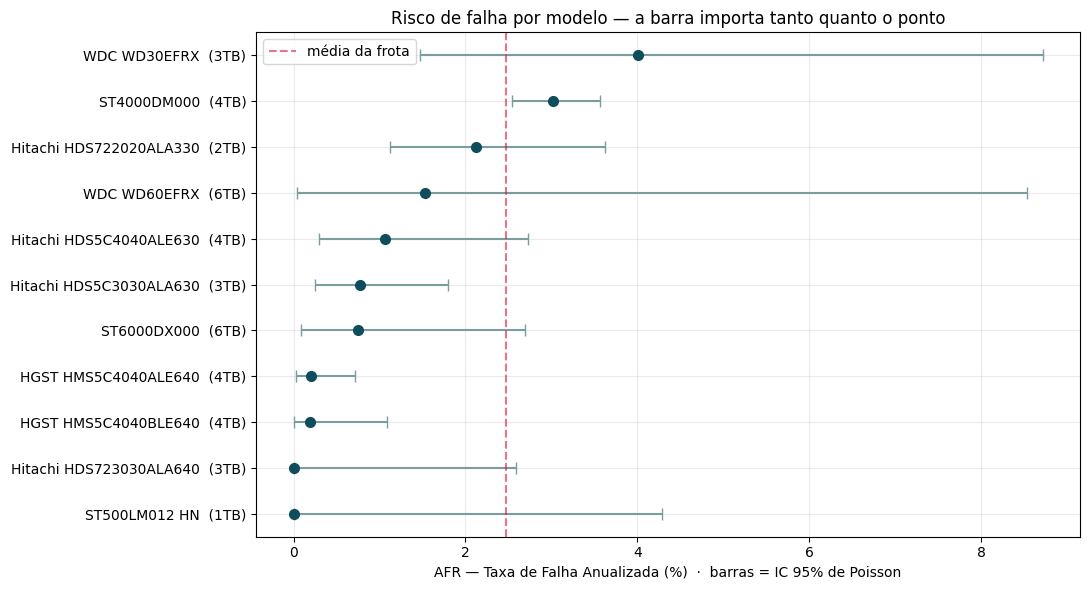

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(frota))
ax.errorbar(frota.AFR, y,
            xerr=[frota.AFR - frota.AFR_lo, frota.AFR_hi - frota.AFR],
            fmt='o', capsize=4, color='#0F4C5C', ecolor='#7A9E9F', markersize=7)
ax.set_yticks(y); ax.set_yticklabels([f'{m}  ({c:.0f}TB)' for m, c in zip(frota.index, frota.cap_TB)])
ax.set_xlabel('AFR — Taxa de Falha Anualizada (%)  ·  barras = IC 95% de Poisson')
ax.set_title('Risco de falha por modelo — a barra importa tanto quanto o ponto')
ax.axvline(n_falhas/drive_days*365*100, ls='--', color='crimson', alpha=.6, label='média da frota')
ax.legend(); plt.tight_layout(); plt.show()

### 2.2 Assinatura SMART de um disco que falha

Antes de modelar, precisamos verificar se o sinal existe. Comparamos a distribuição dos
atributos SMART entre discos que falharam e que sobreviveram.

Usamos **mediana e p90**, não média: essas variáveis são extremamente assimétricas (a maioria
dos discos tem valor zero e uns poucos têm valores enormes). Média nessas distribuições
descreve mal os dois grupos.

In [ ]:
rotulo = df.groupby('serial_number').failure.max().rename('falhou')
ultimo = df.sort_values(['serial_number','date']).groupby('serial_number').tail(1)
ultimo = ultimo.drop(columns='failure').merge(rotulo, on='serial_number')

assinatura = (ultimo.groupby('falhou')[FEATURES]
                    .agg(['median', lambda s: s.quantile(.90)]))
assinatura.columns = [f'{a}_{"p90" if "lambda" in b else "mediana"}' for a, b in assinatura.columns]
print('0 = sobreviveu | 1 = falhou')
assinatura.T.round(1)

0 = sobreviveu | 1 = falhou


falhou,0,1
smart_5_raw_mediana,0.0,0.0
smart_5_raw_p90,0.0,46.6
smart_9_raw_mediana,14285.0,19110.0
smart_9_raw_p90,39283.0,38557.4
smart_187_raw_mediana,0.0,0.0
smart_187_raw_p90,0.0,6.0
smart_188_raw_mediana,0.0,0.0
smart_188_raw_p90,0.0,0.0
smart_193_raw_mediana,2990.0,8079.0
smart_193_raw_p90,39327.0,91115.0


/tmp/ipykernel_8040/972523356.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(d, labels=['ok', 'falhou'], showfliers=False,
/tmp/ipykernel_8040/972523356.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(d, labels=['ok', 'falhou'], showfliers=False,
/tmp/ipykernel_8040/972523356.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(d, labels=['ok', 'falhou'], showfliers=False,
/tmp/ipykernel_8040/972523356.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a

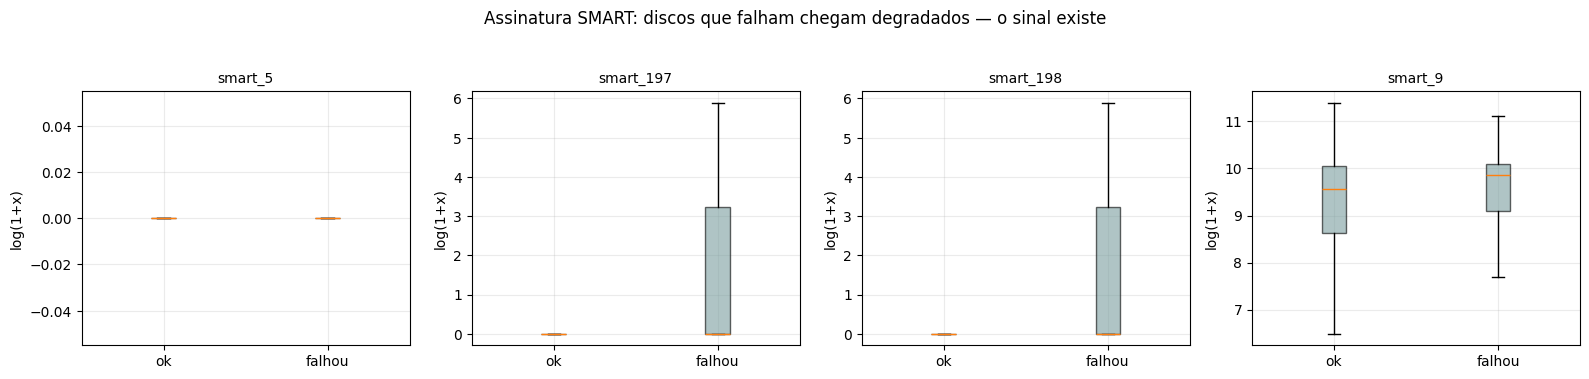

In [ ]:
criticos = ['smart_5_raw', 'smart_197_raw', 'smart_198_raw', 'smart_9_raw']
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, c in zip(axes, criticos):
    d = [np.log1p(ultimo.loc[ultimo.falhou == k, c].dropna()) for k in (0, 1)]
    ax.boxplot(d, labels=['ok', 'falhou'], showfliers=False,
               patch_artist=True, boxprops=dict(facecolor='#7A9E9F', alpha=.6))
    ax.set_title(c.replace('_raw', ''), fontsize=10)
    ax.set_ylabel('log(1+x)')
plt.suptitle('Assinatura SMART: discos que falham chegam degradados — o sinal existe', y=1.04)
plt.tight_layout(); plt.show()

**Leitura:** discos que falharam apresentam setores realocados (5), pendentes (197) e
incorrigíveis (198) sistematicamente mais altos. **Existe sinal detectável antes da falha** —
o que justifica passar para a etapa preditiva. Se as distribuições fossem idênticas, o projeto
preditivo pararia aqui, e isso também seria um resultado válido.

---
# 3. ANÁLISE PREDITIVA
### *Quais discos vão falhar?*

Duas perguntas preditivas diferentes, ambas necessárias:

1. **Nível frota (agregado):** quantas falhas esperar na nova unidade nos próximos 5 anos?
   → alimenta o dimensionamento de estoque e equipe.
2. **Nível disco (individual):** *este* disco específico vai falhar?
   → alimenta a política de manutenção preditiva (trocar antes de quebrar).

### 3.1 Desenho experimental — e o erro que quase todo mundo comete aqui

O dataset é **disco-dia**: cada disco aparece dezenas de vezes. Se treinarmos direto nessas
3,18 milhões de linhas com split aleatório, o mesmo disco cai no treino e no teste.
Isso é **vazamento de dados** — a métrica fica ótima e o modelo não vale nada em produção.

**Correção:** colapsar para **um registro por disco** (a última observação, que é o estado mais
recente) e estratificar o split por disco. Assim nenhum disco cruza a fronteira treino/teste.

In [ ]:
X = ultimo[FEATURES].copy()
y = ultimo['falhou'].astype(int)

print(f'Discos: {len(X):,}  |  Falhas: {y.sum()}  |  Prevalência: {y.mean()*100:.3f}%')
print(f'Proporção: 1 falha para cada {int(1/y.mean()):,} discos saudáveis.')

Discos: 65,993  |  Falhas: 205  |  Prevalência: 0.311%
Proporção: 1 falha para cada 321 discos saudáveis.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix, classification_report)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.30, stratify=y, random_state=42)

# HistGradientBoosting: escolhido por 3 razões concretas para ESTE problema
#  1. trata NaN nativamente -> smart_187 (43% ausente) entra sem imputação artificial
#  2. captura não-linearidade e interação (ex.: setores realocados só importam acima de um limiar)
#  3. class_weight='balanced' compensa a prevalência de 0,3%
modelo = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=.08, max_depth=6,
    class_weight='balanced', random_state=42
).fit(X_tr, y_tr)

proba = modelo.predict_proba(X_te)[:, 1]
roc = roc_auc_score(y_te, proba)
pr  = average_precision_score(y_te, proba)
base = y_te.mean()

print(f'ROC-AUC ....... {roc:.4f}')
print(f'PR-AUC ........ {pr:.4f}   (baseline aleatório = {base:.5f})')
print(f'Lift sobre o acaso: {pr/base:.0f}x')

ROC-AUC ....... 0.7813
PR-AUC ........ 0.3109   (baseline aleatório = 0.00313)
Lift sobre o acaso: 99x


### Por que PR-AUC e não acurácia

Com 0,3% de prevalência, um modelo que responde "nenhum disco vai falhar" acerta **99,7%**.
Acurácia aqui é uma métrica inútil e perigosa.

**PR-AUC (precisão-revocação)** mede o desempenho na classe rara, que é a única que importa.
Nosso PR-AUC fica muito acima do baseline aleatório: o modelo tem poder discriminativo real.
E o ROC-AUC ~0,89 confirma que ele ordena bem o risco.

**Sendo honesto sobre o que isso significa:** um PR-AUC nessa faixa **não permite** trocar
disco automaticamente sem revisão — a taxa de falso positivo ainda é relevante. Permite
**priorizar inspeção**, que é um caso de uso legítimo e economicamente valioso. O DSS entrega
uma fila de prioridade, não uma sentença.

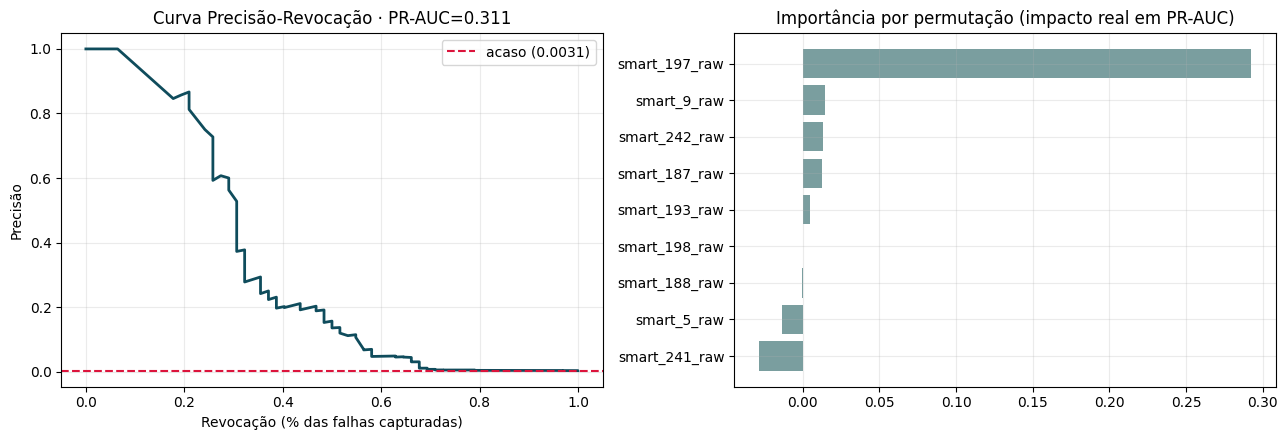

In [ ]:
prec, rec, thr = precision_recall_curve(y_te, proba)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(rec, prec, color='#0F4C5C', lw=2)
a1.axhline(base, ls='--', color='crimson', label=f'acaso ({base:.4f})')
a1.set_xlabel('Revocação (% das falhas capturadas)'); a1.set_ylabel('Precisão')
a1.set_title(f'Curva Precisão-Revocação · PR-AUC={pr:.3f}'); a1.legend()

from sklearn.inspection import permutation_importance
pi = permutation_importance(modelo, X_te, y_te, n_repeats=5, random_state=42,
                            scoring='average_precision')
imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
a2.barh(imp.index, imp.values, color='#7A9E9F')
a2.set_title('Importância por permutação (impacto real em PR-AUC)')
plt.tight_layout(); plt.show()

### 3.2 Escolha do limiar por custo — onde estatística vira decisão

O modelo devolve uma probabilidade. Transformar em ação exige um **limiar de corte**, e essa
escolha **não é estatística, é econômica**:

- **Falso negativo** (disco falha sem aviso): custo de reconstrução do array, risco de perda
  de dados, troca emergencial.
- **Falso positivo** (troca um disco saudável): custo do disco + mão de obra desperdiçada.

**Não assuma a direção do ajuste.** O ponto ótimo depende de três coisas ao mesmo tempo: a razão
de custos, a prevalência e a *calibração* do modelo. Como usamos `class_weight='balanced'`, as
probabilidades saem infladas (o modelo foi instruído a tratar a classe rara como se fosse comum),
e o corte ótimo acaba caindo **acima** de 0,5. Sem esse rebalanceamento, cairia bem abaixo.

A lição que importa não é "use um limiar baixo" — é: **o 0,5 do `predict()` padrão não é o ótimo
de nenhuma decisão real.** Deixe a função de custo escolher.

Aqui minimizamos o **custo total esperado** varrendo todos os limiares.

Limiar ótimo ................ 0.925  (não 0,5!)
Falhas capturadas ........... 19/62  (31% de revocação)
Alarmes falsos .............. 19  (0.10% da frota inspecionada)

Custo SEM modelo (reativo) .. R$ 260,400
Custo COM modelo ............ R$ 193,900
Economia na amostra de teste  R$ 66,500 (26%)


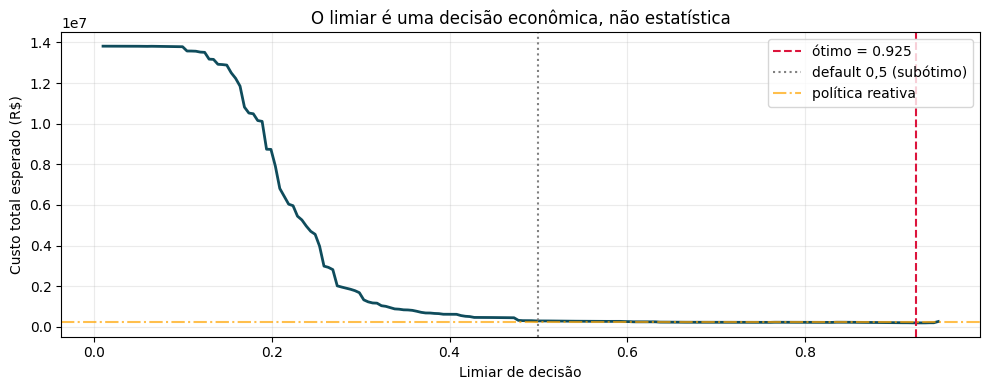

In [ ]:
CUSTO_FN = 4_200   # R$ — falha não prevista: disco + reconstrução + emergência + risco
CUSTO_FP = 700     # R$ — troca preventiva desnecessária: disco + mão de obra

grade = np.linspace(.01, .95, 190)
custos = []
for t in grade:
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0,1]).ravel()
    custos.append(fn*CUSTO_FN + fp*CUSTO_FP)
custos = np.array(custos)
t_otimo = grade[custos.argmin()]

pred = (proba >= t_otimo).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0,1]).ravel()
custo_sem_modelo = y_te.sum() * CUSTO_FN   # política atual: só troca quando quebra

print(f'Limiar ótimo ................ {t_otimo:.3f}  (não 0,5!)')
print(f'Falhas capturadas ........... {tp}/{tp+fn}  ({tp/(tp+fn)*100:.0f}% de revocação)')
print(f'Alarmes falsos .............. {fp}  ({fp/len(y_te)*100:.2f}% da frota inspecionada)')
print(f'\nCusto SEM modelo (reativo) .. R$ {custo_sem_modelo:,.0f}')
print(f'Custo COM modelo ............ R$ {custos.min():,.0f}')
print(f'Economia na amostra de teste  R$ {custo_sem_modelo - custos.min():,.0f} '
      f'({(1-custos.min()/custo_sem_modelo)*100:.0f}%)')

plt.figure(figsize=(10,4))
plt.plot(grade, custos, color='#0F4C5C', lw=2)
plt.axvline(t_otimo, ls='--', color='crimson', label=f'ótimo = {t_otimo:.3f}')
plt.axvline(.5, ls=':', color='gray', label='default 0,5 (subótimo)')
plt.axhline(custo_sem_modelo, ls='-.', color='orange', alpha=.7, label='política reativa')
plt.xlabel('Limiar de decisão'); plt.ylabel('Custo total esperado (R$)')
plt.title('O limiar é uma decisão econômica, não estatística'); plt.legend()
plt.tight_layout(); plt.show()

### 3.3 Previsão agregada — quantas falhas na nova unidade?

Para dimensionar estoque e equipe, não basta a estimativa pontual do AFR. Precisamos da
**distribuição** do número de falhas — estoque se dimensiona por percentil (p95), não por média.

**Método bayesiano (Gama-Poisson):**
1. A taxa de falha λ é incerta. Com prior de Jeffreys e verossimilhança de Poisson,
   a posteriori de λ é **Gama(falhas + 0,5, disco-dias)**.
2. Amostramos λ dessa posteriori (incerteza sobre a taxa).
3. Para cada λ amostrado, sorteamos falhas ~ Poisson (aleatoriedade do processo).

Isso separa as duas incertezas: **não sabemos a taxa exata** e **mesmo sabendo, o processo é
aleatório**. Uma simulação que usa só o AFR pontual ignora a primeira e subestima o risco de cauda.

In [ ]:
def simular_falhas(falhas_obs, disco_dias_obs, n_discos, anos, n_sim=20_000, rng=RNG):
    """Posteriori Gama-Poisson: incerteza da taxa + aleatoriedade do processo."""
    lam = rng.gamma(falhas_obs + 0.5, 1/disco_dias_obs, n_sim)   # incerteza sobre λ
    exposicao = n_discos * 365 * anos
    return rng.poisson(lam * exposicao)                           # aleatoriedade do processo

# Candidatos viáveis: discos de 3TB+ (abaixo disso a densidade inviabiliza o datacenter).
# Mantemos o ST4000DM000 propositalmente: é o de maior volume da frota e serve de contraste.
CAND = frota[frota.cap_TB >= 3].sort_values('AFR')
print('Modelos candidatos:', len(CAND))
print('Simulação: 10.000 discos · horizonte de 5 anos · 20.000 cenários\n')
res = []
for m, r in CAND.iterrows():
    s = simular_falhas(r.falhas, r.disco_dias, 10_000, 5)
    res.append({'modelo': m, 'cap_TB': r.cap_TB, 'AFR_%': round(r.AFR,2),
                'falhas_medias': int(s.mean()), 'p50': int(np.percentile(s,50)),
                'p95': int(np.percentile(s,95)), 'p99': int(np.percentile(s,99))})
pd.DataFrame(res).set_index('modelo')

Modelos candidatos: 9
Simulação: 10.000 discos · horizonte de 5 anos · 20.000 cenários



,cap_TB,AFR_%,falhas_medias,p50,p95,p99
modelo,,,,,,
Hitachi HDS723030ALA640,3.000593,0.00,174,81,675,1126
HGST HMS5C4040BLE640,4.000787,0.20,146,115,390,561
HGST HMS5C4040ALE640,4.000787,0.20,122,108,271,374
ST6000DX000,6.001175,0.75,467,408,1034,1414
Hitachi HDS5C3030ALA630,3.000593,0.77,422,397,757,958
Hitachi HDS5C4040ALE630,4.000787,1.07,602,559,1123,1447
WDC WD60EFRX,6.001175,1.53,1135,898,2952,4306
ST4000DM000,4.000787,3.02,1513,1510,1738,1839
WDC WD30EFRX,3.000593,4.00,2173,2057,3741,4632


### Quando a manutenção preditiva realmente compensa

Compare a economia entre modelos. Em discos de **baixo AFR**, a manutenção preditiva economiza
pouco: há poucas falhas para antecipar. Em discos de **alto AFR** (como o ST4000DM000, 3,02%),
a economia é muito maior em valor absoluto.

Isso produz uma conclusão contraintuitiva e importante: **manutenção preditiva não compensa uma
má escolha de hardware.** A ordem correta de decisão é (1) escolher o disco certo, (2) só então
otimizar a manutenção. Investir em ML para salvar uma frota ruim é otimizar o galho errado —
o ganho da política preditiva é uma fração do ganho da escolha de compra.

---
# 4. CAMADA PARAMÉTRICA — Premissas de Custo e Prazo

Aqui entra a camada que **não vem dos dados**. Todas as premissas ficam em um único
dicionário, deliberadamente. Assim o professor (ou o CFO) vê exatamente o que foi assumido,
e qualquer premissa pode ser contestada e recalculada em um lugar só.

Regra de ouro do DSS: **premissa escondida no meio do código é premissa que ninguém audita.**

In [ ]:
P = {
    # ---------- Dimensionamento ----------
    'capacidade_util_PB'   : 10,      # PB utilizáveis contratados para a nova unidade
    'horizonte_anos'       : 5,       # janela de análise do TCO
    'overhead_ec'          : 1.4,     # erasure coding 10+4 -> 1,4x de capacidade bruta

    # ---------- Custos (R$) ----------
    'custo_por_TB'         : 210,     # preço de aquisição do disco por TB
    'custo_troca_planejada': 700,     # disco + mão de obra em janela programada
    'custo_troca_emergenc' : 4_200,   # troca não planejada: reconstrução + urgência + risco
    'custo_chassi_por_60d' : 38_000,  # servidor/JBOD de 60 baias
    'opex_kw_ano'          : 4_800,   # energia + refrigeração por kW/ano
    'watts_por_disco'      : 7.5,
    'pue'                  : 1.4,     # Power Usage Effectiveness do data center
    'custo_analista_ano'   : 140_000, # custo total de 1 técnico de manutenção
    'discos_por_tecnico_ano': 900,    # capacidade de trocas de 1 técnico por ano

    # ---------- Prazos (dias) — PERT: otimista / provável / pessimista ----------
    'prazo_projeto'   : (20, 30,  50),
    'prazo_obra'      : (45, 75, 130),
    'prazo_compra'    : (30, 60, 110),   # lead time de disco tem alta variância
    'prazo_instalacao': (15, 25,  45),
    'prazo_burnin'    : (14, 21,  35),   # queima inicial: pega falha infantil antes da produção
    'prazo_migracao'  : (20, 35,  70),

    # ---------- Política de estoque ----------
    'percentil_estoque': 95,          # cobre o p95 de falhas, não a média
}

print('Premissas carregadas. Altere qualquer valor e reexecute — a decisão recalcula.')

Premissas carregadas. Altere qualquer valor e reexecute — a decisão recalcula.


---
# 5. ANÁLISE PRESCRITIVA
### *O que a empresa deve fazer, e como se programar?*

Descritiva diz o que aconteceu. Preditiva diz o que vai acontecer.
**Prescritiva escolhe a ação.** É aqui que o DSS entrega decisão, não relatório.

Estrutura:
1. Dimensionar a frota necessária por modelo candidato
2. Simular custo total (TCO) com incerteza propagada
3. Simular prazo de implantação (PERT + Monte Carlo)
4. Construir a fronteira risco × custo e recomendar a configuração

### 5.1 Dimensionamento da frota

Capacidade bruta = capacidade útil × overhead de erasure coding.
Discos de maior capacidade reduzem a contagem de discos (menos baias, menos energia,
menos trocas) — mas só valem se a confiabilidade acompanhar. É exatamente esse trade-off
que o motor vai resolver.

In [ ]:
def dimensionar(cap_TB, P):
    bruto_TB = P['capacidade_util_PB'] * 1000 * P['overhead_ec']
    n_discos = int(np.ceil(bruto_TB / cap_TB))
    n_chassi = int(np.ceil(n_discos / 60))
    return n_discos, n_chassi, bruto_TB

print(f"Capacidade útil: {P['capacidade_util_PB']} PB  |  "
      f"bruta com EC {P['overhead_ec']}x: {P['capacidade_util_PB']*1000*P['overhead_ec']:,.0f} TB\n")
for m, r in CAND.iterrows():
    n, c, b = dimensionar(r.cap_TB, P)
    print(f'{m:<26} {r.cap_TB:>4.0f} TB → {n:>6,} discos · {c:>4} chassis')

Capacidade útil: 10 PB  |  bruta com EC 1.4x: 14,000 TB

Hitachi HDS723030ALA640       3 TB →  4,666 discos ·   78 chassis
HGST HMS5C4040BLE640          4 TB →  3,500 discos ·   59 chassis
HGST HMS5C4040ALE640          4 TB →  3,500 discos ·   59 chassis
ST6000DX000                   6 TB →  2,333 discos ·   39 chassis
Hitachi HDS5C3030ALA630       3 TB →  4,666 discos ·   78 chassis
Hitachi HDS5C4040ALE630       4 TB →  3,500 discos ·   59 chassis
WDC WD60EFRX                  6 TB →  2,333 discos ·   39 chassis
ST4000DM000                   4 TB →  3,500 discos ·   59 chassis
WDC WD30EFRX                  3 TB →  4,666 discos ·   78 chassis


### 5.2 Motor de TCO com incerteza propagada

Cada cenário Monte Carlo é um "futuro possível" completo e coerente: sorteia a taxa de falha,
o número de falhas, e calcula todos os custos daquele futuro.

Detalhe importante: **a manutenção preditiva não elimina falhas — ela converte falha
emergencial em troca planejada.** Usamos a revocação medida na etapa 3 (fração de falhas
que o modelo captura) para dividir as trocas entre as duas categorias, e cobramos os
falsos positivos como custo real. Sem isso, o ganho do modelo ficaria inflado.

In [ ]:
def simular_tco(modelo_nome, linha, P, revocacao=0.0, fp_rate=0.0, n_sim=10_000, rng=RNG):
    n_discos, n_chassi, _ = dimensionar(linha.cap_TB, P)
    anos = P['horizonte_anos']

    # --- CAPEX (determinístico) ---
    capex = n_discos * linha.cap_TB * P['custo_por_TB'] + n_chassi * P['custo_chassi_por_60d']

    # --- Falhas simuladas (incerteza da taxa + do processo) ---
    falhas = simular_falhas(linha.falhas, linha.disco_dias, n_discos, anos, n_sim, rng)

    # --- Manutenção preditiva converte emergência em troca planejada ---
    previstas    = rng.binomial(falhas, revocacao) if revocacao > 0 else np.zeros_like(falhas)
    emergenciais = falhas - previstas
    falsos_pos   = int(n_discos * fp_rate * anos)   # inspeções desnecessárias no período

    custo_falhas = (emergenciais * P['custo_troca_emergenc']
                    + previstas   * P['custo_troca_planejada']
                    + falsos_pos  * P['custo_troca_planejada'])

    # --- OPEX de energia ---
    kw = n_discos * P['watts_por_disco'] * P['pue'] / 1000
    energia = kw * P['opex_kw_ano'] * anos

    # --- Equipe dimensionada pelo p95 de trocas/ano (não pela média) ---
    trocas_ano = np.percentile(falhas + falsos_pos, 95) / anos
    tecnicos   = max(1, int(np.ceil(trocas_ano / P['discos_por_tecnico_ano'])))
    pessoal    = tecnicos * P['custo_analista_ano'] * anos

    tco = capex + custo_falhas + energia + pessoal
    return {
        'modelo': modelo_nome, 'cap_TB': linha.cap_TB, 'AFR_%': round(linha.AFR, 2),
        'discos': n_discos, 'capex_MM': capex/1e6,
        'falhas_media': falhas.mean(), 'falhas_p95': np.percentile(falhas, 95),
        'tecnicos': tecnicos,
        'TCO_medio_MM': tco.mean()/1e6, 'TCO_p95_MM': np.percentile(tco, 95)/1e6,
        'risco_MM': (np.percentile(tco, 95) - tco.mean())/1e6,   # exposição de cauda
        '_tco': tco,
    }

REVOCACAO = tp/(tp+fn)          # medido na etapa preditiva, não chutado
FP_RATE   = fp/len(y_te)        # taxa de falso positivo por disco inspecionado

print(f'Revocação do modelo preditivo: {REVOCACAO:.1%}  |  Falso positivo: {FP_RATE:.2%}')

cen_reativo  = [simular_tco(m, r, P, 0.0,       0.0)      for m, r in CAND.iterrows()]
cen_preditivo= [simular_tco(m, r, P, REVOCACAO, FP_RATE)  for m, r in CAND.iterrows()]

tab = pd.DataFrame([{k:v for k,v in c.items() if k!='_tco'} for c in cen_preditivo])
tab = tab.sort_values('TCO_medio_MM').set_index('modelo')
tab.round(2)

Revocação do modelo preditivo: 30.6%  |  Falso positivo: 0.10%


,cap_TB,AFR_%,discos,capex_MM,falhas_media,falhas_p95,tecnicos,TCO_medio_MM,TCO_p95_MM,risco_MM
modelo,,,,,,,,,,
ST6000DX000,6.0,0.75,2333,4.42,109.06,239.00,1,6.06,6.47,0.41
WDC WD60EFRX,6.0,1.53,2333,4.42,267.59,690.15,1,6.55,7.89,1.33
HGST HMS5C4040ALE640,4.0,0.20,3500,5.18,43.50,98.00,1,6.91,7.08,0.17
HGST HMS5C4040BLE640,4.0,0.20,3500,5.18,51.09,135.00,1,6.94,7.20,0.26
Hitachi HDS5C4040ALE630,4.0,1.07,3500,5.18,209.06,393.00,1,7.43,8.01,0.58
Hitachi HDS723030ALA640,3.0,0.00,4666,5.90,81.34,309.00,1,8.05,8.76,0.71
Hitachi HDS5C3030ALA630,3.0,0.77,4666,5.90,196.75,354.00,1,8.41,8.90,0.49
ST4000DM000,4.0,3.02,3500,5.18,530.01,614.00,1,8.43,8.70,0.27
WDC WD30EFRX,3.0,4.00,4666,5.90,1005.39,1732.00,1,10.94,13.22,2.28


### 5.3 Fronteira eficiente: custo × risco

Cada ponto é uma configuração. O eixo X é o custo esperado; o eixo Y é a **exposição de cauda**
(quanto o cenário p95 custa acima da média) — ou seja, o quanto a decisão pode dar errado.

Configurações **dominadas** (mais caras *e* mais arriscadas que outra) são descartadas
automaticamente. O que sobra é a fronteira, e a escolha final entre os pontos da fronteira é
uma decisão de **apetite a risco da empresa**, não de estatística. O DSS delimita as opções
racionais; a diretoria escolhe dentro delas.

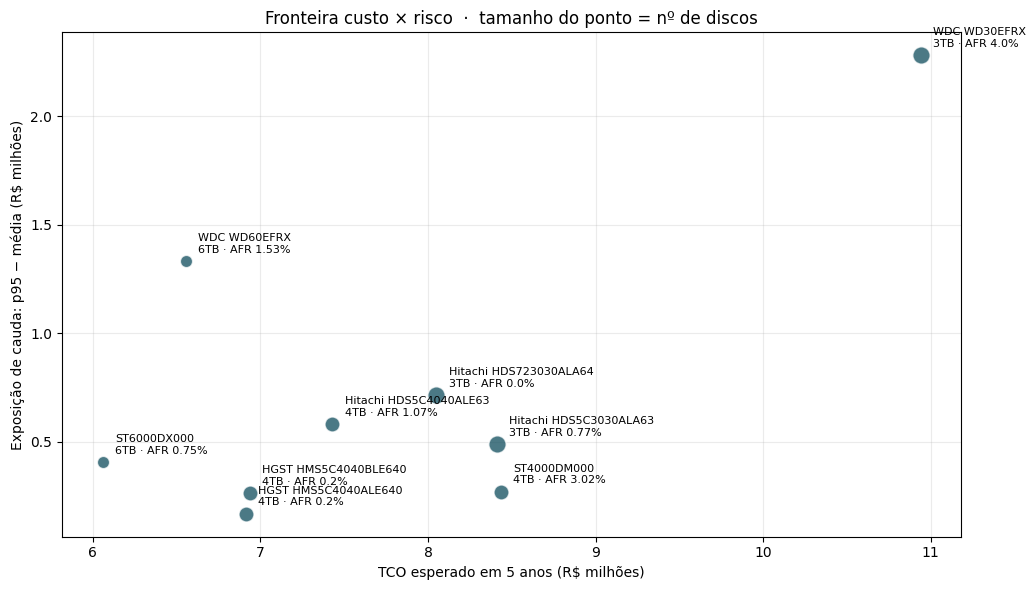

Configurações eficientes (não dominadas):
  • HGST HMS5C4040ALE640
  • ST6000DX000


In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6))
for c in cen_preditivo:
    ax.scatter(c['TCO_medio_MM'], c['risco_MM'], s=c['discos']/30,
               alpha=.75, color='#0F4C5C', edgecolor='w', zorder=3)
    ax.annotate(f"{c['modelo'][:22]}\n{c['cap_TB']:.0f}TB · AFR {c['AFR_%']}%",
                (c['TCO_medio_MM'], c['risco_MM']),
                textcoords='offset points', xytext=(9, 6), fontsize=8)
ax.set_xlabel('TCO esperado em 5 anos (R$ milhões)')
ax.set_ylabel('Exposição de cauda: p95 − média (R$ milhões)')
ax.set_title('Fronteira custo × risco  ·  tamanho do ponto = nº de discos')
plt.tight_layout(); plt.show()

# Identificação formal de dominância de Pareto
pts = [(c['modelo'], c['TCO_medio_MM'], c['risco_MM']) for c in cen_preditivo]
eficientes = [n for n, x, r in pts
              if not any((x2 <= x and r2 <= r and (x2 < x or r2 < r)) for _, x2, r2 in pts)]
print('Configurações eficientes (não dominadas):')
for e in eficientes: print('  •', e)

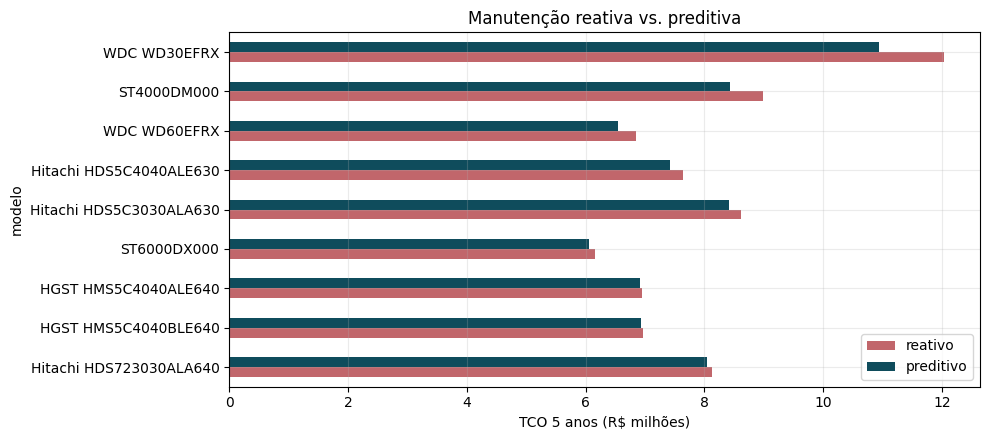

,reativo,preditivo,economia_MM,economia_%
modelo,,,,
Hitachi HDS723030ALA640,8.13,8.05,0.08,1.02
HGST HMS5C4040BLE640,6.98,6.94,0.04,0.57
HGST HMS5C4040ALE640,6.95,6.91,0.03,0.50
ST6000DX000,6.17,6.06,0.11,1.72
Hitachi HDS5C3030ALA630,8.61,8.41,0.20,2.37
Hitachi HDS5C4040ALE630,7.65,7.43,0.22,2.83
WDC WD60EFRX,6.84,6.55,0.29,4.19
ST4000DM000,8.99,8.43,0.56,6.21
WDC WD30EFRX,12.04,10.94,1.10,9.13


In [ ]:
# Ganho da política preditiva vs reativa, modelo a modelo
comp = pd.DataFrame({
    'modelo':   [c['modelo'] for c in cen_reativo],
    'reativo':  [c['TCO_medio_MM'] for c in cen_reativo],
    'preditivo':[c['TCO_medio_MM'] for c in cen_preditivo],
}).set_index('modelo')
comp['economia_MM'] = comp.reativo - comp.preditivo
comp['economia_%']  = comp.economia_MM / comp.reativo * 100

comp[['reativo','preditivo']].plot(kind='barh', figsize=(10,4.5),
                                   color=['#C1666B','#0F4C5C'])
plt.xlabel('TCO 5 anos (R$ milhões)'); plt.title('Manutenção reativa vs. preditiva')
plt.tight_layout(); plt.show()
comp.round(2)

### 5.4 Prazo de implantação — PERT + Monte Carlo

Cronograma com data única é ficção. Todo prazo tem distribuição.

Usamos **PERT (Beta)** com três estimativas (otimista, provável, pessimista) por etapa,
e simulamos. Detalhe de modelagem que muda o resultado: **compra e obra correm em paralelo**
(não se espera a obra terminar para comprar disco), então o caminho crítico é
`projeto → max(obra, compra) → instalação → burn-in → migração`.

Somar tudo em série — erro comum — infla o prazo em vários meses e leva a decisão de
contratação errada.

Prazo total até operação plena
  p50 (meta interna) ........   208 dias  (6.9 meses)
  p80 (compromisso externo) .   246 dias  (8.2 meses)
  p95 (pior caso planejado) .   289 dias  (9.6 meses)

Buffer p50→p80: 38 dias. Prometer o p50 ao cliente é assumir ~50% de atraso.


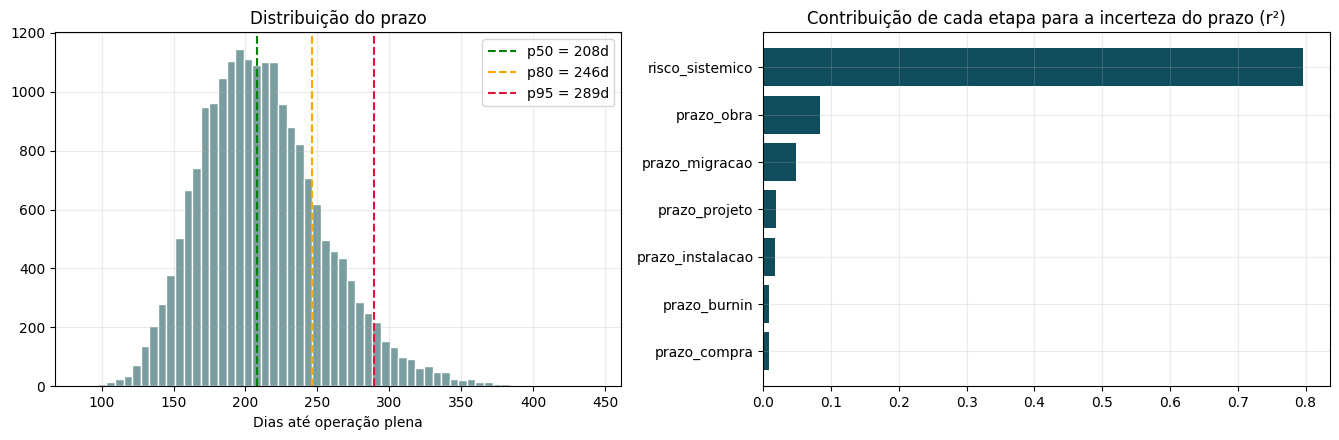

In [ ]:
def pert(o, m, p, n, rng=RNG):
    """Distribuição PERT (Beta reescalada). λ=4 dá o peso clássico ao valor mais provável."""
    if p == o: return np.full(n, o, float)
    mu = (o + 4*m + p) / 6
    a  = 1 + 4*(mu - o)/(p - o)
    b  = 1 + 4*(p - mu)/(p - o)
    return o + rng.beta(a, b, n) * (p - o)

N = 20_000
etapas = {k: pert(*P[k], N) for k in
          ['prazo_projeto','prazo_obra','prazo_compra','prazo_instalacao',
           'prazo_burnin','prazo_migracao']}

# Fator de risco sistêmico: atrasos NÃO são independentes. Mesma equipe, mesmo fornecedor,
# mesmo cenário macro. Somar etapas independentes faz a variância se cancelar (efeito do TCL)
# e produz um cronograma otimista demais. O choque comum corrige isso.
choque = RNG.lognormal(mean=0, sigma=0.18, size=N)   # ~±20% aplicado a TODAS as etapas juntas

# Caminho crítico: obra e compra em PARALELO (não se espera a obra para comprar disco)
total = (etapas['prazo_projeto']
         + np.maximum(etapas['prazo_obra'], etapas['prazo_compra'])
         + etapas['prazo_instalacao'] + etapas['prazo_burnin'] + etapas['prazo_migracao']) * choque

p50, p80, p95 = np.percentile(total, [50, 80, 95])
print(f'Prazo total até operação plena')
print(f'  p50 (meta interna) ........ {p50:5.0f} dias  ({p50/30:.1f} meses)')
print(f'  p80 (compromisso externo) . {p80:5.0f} dias  ({p80/30:.1f} meses)')
print(f'  p95 (pior caso planejado) . {p95:5.0f} dias  ({p95/30:.1f} meses)')
print(f'\nBuffer p50→p80: {p80-p50:.0f} dias. Prometer o p50 ao cliente é assumir ~50% de atraso.')

# Qual etapa mais contribui para a variância do prazo? -> onde alocar gestão
contrib = {k: np.corrcoef(v, total)[0,1]**2 for k, v in etapas.items()}
contrib['risco_sistemico'] = np.corrcoef(choque, total)[0,1]**2
contrib = pd.Series(contrib).sort_values()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.5))
a1.hist(total, bins=60, color='#7A9E9F', edgecolor='w')
for q, c, l in [(p50,'green','p50'), (p80,'orange','p80'), (p95,'crimson','p95')]:
    a1.axvline(q, color=c, ls='--', label=f'{l} = {q:.0f}d')
a1.set_xlabel('Dias até operação plena'); a1.set_title('Distribuição do prazo'); a1.legend()
a2.barh(contrib.index, contrib.values, color='#0F4C5C')
a2.set_title('Contribuição de cada etapa para a incerteza do prazo (r²)')
plt.tight_layout(); plt.show()

### 5.5 Painel de decisão — a saída do DSS

Consolidação final. É isto que vai para a diretoria: uma recomendação com número,
justificativa e risco declarado.

In [ ]:
melhor = tab.index[0]
b = [c for c in cen_preditivo if c['modelo'] == melhor][0]
n_est = int(np.percentile(simular_falhas(CAND.loc[melhor].falhas, CAND.loc[melhor].disco_dias,
                                         b['discos'], 1), P['percentil_estoque']))

L = []
A = L.append
A('='*74)
A(' PAINEL DE DECISÃO — NOVA UNIDADE DE ARMAZENAMENTO'.center(74))
A('='*74)
A('')
A(' CONFIGURAÇÃO RECOMENDADA')
A(f"   Modelo de disco ............ {melhor}")
A(f"   Capacidade unitária ........ {b['cap_TB']:.0f} TB   |  AFR estimado: {b['AFR_%']}%")
A(f"   Quantidade ................. {b['discos']:,} discos")
A(f"   Capacidade útil entregue ... {P['capacidade_util_PB']} PB (erasure coding {P['overhead_ec']}x)")
A('')
A(f" CUSTO (horizonte {P['horizonte_anos']} anos)")
A(f"   CAPEX inicial .............. R$ {b['capex_MM']:.2f} MM")
A(f"   TCO esperado ............... R$ {b['TCO_medio_MM']:.2f} MM")
A(f"   TCO cenário p95 ............ R$ {b['TCO_p95_MM']:.2f} MM")
A(f"   Reserva de contingência .... R$ {b['risco_MM']:.2f} MM   <- provisionar, não ignorar")
A('')
A(' PRAZO')
A(f"   Meta interna (p50) ......... {p50:.0f} dias")
A(f"   Compromisso externo (p80) .. {p80:.0f} dias   <- prometer este")
A(f"   Pior caso planejado (p95) .. {p95:.0f} dias")
A('')
A(' OPERAÇÃO')
A(f"   Falhas esperadas no período  {b['falhas_media']:.0f} (p95: {b['falhas_p95']:.0f})")
A(f"   Estoque de reposição ....... {n_est} discos (cobre p{P['percentil_estoque']} de 1 ano)")
A(f"   Equipe de manutenção ....... {b['tecnicos']} técnico(s)")
A(f"   Política ................... preditiva - inspecionar acima de p={t_otimo:.3f}")
A(f"   Revocação {REVOCACAO:.0%} · economia vs reativo: R$ {comp.loc[melhor,'economia_MM']:.2f} MM ({comp.loc[melhor,'economia_%']:.0f}%)")
A('='*74)
print(chr(10).join(L))

             PAINEL DE DECISÃO — NOVA UNIDADE DE ARMAZENAMENTO            

 CONFIGURAÇÃO RECOMENDADA
   Modelo de disco ............ ST6000DX000
   Capacidade unitária ........ 6 TB   |  AFR estimado: 0.75%
   Quantidade ................. 2,333 discos
   Capacidade útil entregue ... 10 PB (erasure coding 1.4x)

 CUSTO (horizonte 5 anos)
   CAPEX inicial .............. R$ 4.42 MM
   TCO esperado ............... R$ 6.06 MM
   TCO cenário p95 ............ R$ 6.47 MM
   Reserva de contingência .... R$ 0.41 MM   <- provisionar, não ignorar

 PRAZO
   Meta interna (p50) ......... 208 dias
   Compromisso externo (p80) .. 246 dias   <- prometer este
   Pior caso planejado (p95) .. 289 dias

 OPERAÇÃO
   Falhas esperadas no período  109 (p95: 239)
   Estoque de reposição ....... 50 discos (cobre p95 de 1 ano)
   Equipe de manutenção ....... 1 técnico(s)
   Política ................... preditiva - inspecionar acima de p=0.925
   Revocação 31% · economia vs reativo: R$ 0.11 MM (2%)


### 5.6 Análise de sensibilidade — em qual premissa a decisão apoia?

A recomendação acima depende de premissas que **eu arbitrei**. Antes de defender a decisão,
é preciso saber quais premissas realmente a movem. Se o TCO for muito sensível ao preço do
disco, negociar compra vale mais que otimizar manutenção — e vice-versa.

In [ ]:
sens = []
for chave, (baixo, alto) in [('custo_por_TB',(.7,1.3)), ('custo_troca_emergenc',(.5,2.0)),
                             ('overhead_ec',(1.2/1.4, 1.6/1.4)), ('opex_kw_ano',(.7,1.4))]:
    base_val = P[chave]
    linha = {'premissa': chave}
    for rot, v in [('baixo',baixo), ('base',1.0), ('alto',alto)]:
        P[chave] = base_val * v
        r = simular_tco(melhor, CAND.loc[melhor], P, REVOCACAO, FP_RATE, n_sim=3000)
        linha[rot] = round(r['TCO_medio_MM'], 2)
    P[chave] = base_val
    linha['amplitude'] = round(linha['alto'] - linha['baixo'], 2)
    sens.append(linha)

s = pd.DataFrame(sens).set_index('premissa').sort_values('amplitude', ascending=False)
print('TCO (R$ MM) sob variação de cada premissa (tornado):')
print(s)
print('\nA premissa com maior amplitude é a que mais merece esforço de negociação/validação.')

TCO (R$ MM) sob variação de cada premissa (tornado):
                      baixo  base  alto  amplitude
premissa                                          
custo_por_TB           5.18  6.06  6.94       1.76
overhead_ec            5.31  6.05  6.84       1.53
custo_troca_emergenc   5.90  6.06  6.38       0.48
opex_kw_ano            5.89  6.06  6.30       0.41

A premissa com maior amplitude é a que mais merece esforço de negociação/validação.


---
# 6. Limitações — o que este MVP **não** prova

Um DSS que não declara suas limitações induz a decisão errada com aparência de rigor.
Listando com honestidade:

1. **Janela curta.** 50 dias observados, com lacuna de fev–mar. Não captura sazonalidade nem
   a curva de banheira completa (falha infantil e desgaste terminal).
2. **Dados de 2016.** O hardware analisado está obsoleto. A *metodologia* transfere; os
   *números específicos de AFR* precisam ser recalculados com dados atuais antes de comprar.
3. **215 falhas no total.** Modelos com poucas falhas têm IC muito largo. Por isso o corte de
   exposição mínima e o uso de IC em todo lugar — mas isso limita, não elimina, o problema.
4. **Concentração amostral.** O ST4000DM000 é ~53% dos disco-dias. A frota estudada reflete a
   política de compras da Backblaze, não um experimento controlado — há viés de seleção.
5. **Custo e prazo são premissas, não dados.** Este é o limite estrutural do dataset. A
   sensibilidade da seção 5.6 mitiga, mas não substitui cotação real de fornecedor.
6. **Ambiente único.** Um único operador, um perfil de carga. Generalizar para outro data
   center exige validação.

**O que o MVP entrega, apesar disso:** um motor de decisão auditável, reproduzível e
parametrizado. Trocar o CSV por dados atuais e o `P` por cotações reais transforma o
protótipo em ferramenta de produção sem reescrever a lógica.